# NNI Margin Distribution — Across Tree Sizes

Samples edge-length distributions for random trees across $n \in [5,9]$, computes the minimum NNI margin under each prior, and plots the resulting distributions, per-tree loss rates, and topological feature analyses.
All computation is cached; set the `FORCE_RECOMPUTE_*` flags to regenerate.

In [ ]:
# ── Recompute flags ───────────────────────────────────────────────────────────
FORCE_RECOMPUTE_DELTAS            = False
FORCE_RECOMPUTE_MARGINS           = False
FORCE_RECOMPUTE_WINNING_NEIGHBORS = False

# ── Analysis parameters ───────────────────────────────────────────────────────
N_LEAVES_LIST = [5, 6, 7, 8, 9]
N_TREES       = 500
ALPHA         = 0.20
BETA          = 0.01
N_SAMPLES     = 1000
SEED          = 42

# ── Output paths ──────────────────────────────────────────────────────────────
MULTIPAGE_FIGURE_PATH = "../figures/NNI_neighbors.pdf"

In [2]:
import sys
from pathlib import Path

import matplotlib as mpl
from matplotlib.backends.backend_pdf import PdfPages

cwd = Path.cwd().resolve()
src_candidates = [cwd / "src", cwd.parent / "src", cwd.parent.parent / "src"]
SRC_DIR = next((c for c in src_candidates if c.exists()), None)
if SRC_DIR is None:
    raise RuntimeError("Could not infer the src directory from the current working directory.")
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from inconsistency_generation.repo_paths import get_repo_root
from inconsistency_generation.nni_delta_precomputation import (
    default_flip_weights,
    default_nni_delta_cache_path,
    load_or_compute_nni_delta_bundle,
)
from inconsistency_generation.nni_margin_analysis import (
    compute_topology_feature_analysis,
    default_winning_neighbor_cache_path,
    default_margin_cache_path,
    default_priors,
    load_or_compute_winning_neighbor_feature_diffs,
    load_or_compute_margin_across_n_results,
)
from inconsistency_generation.nni_margin_plots import (
    finalize_figure,
    plot_margin_across_n_figure,
    plot_topology_figure,
    plot_all_topology_features,
    plot_winning_neighbor_heatmap,
)

REPO_ROOT = get_repo_root(cwd)
CACHE_DIR = REPO_ROOT / "cached_data"
FIGURES_DIR = REPO_ROOT / "figures"
CACHE_DIR.mkdir(exist_ok=True)
FIGURES_DIR.mkdir(exist_ok=True)

mpl.rcParams["figure.dpi"] = 150

In [3]:
W_P, W_N = default_flip_weights(ALPHA, BETA)
PRIORS = default_priors()

DELTA_CACHE_PATH = default_nni_delta_cache_path(
    cache_dir=CACHE_DIR, n_leaves_list=N_LEAVES_LIST, n_trees=N_TREES,
    alpha=ALPHA, beta=BETA, seed=SEED, w_pos=W_P, w_neg=W_N,
)
MARGIN_CACHE_PATH = default_margin_cache_path(
    cache_dir=CACHE_DIR, n_leaves_list=N_LEAVES_LIST, n_trees=N_TREES,
    n_samples=N_SAMPLES, alpha=ALPHA, beta=BETA, seed=SEED,
)
WINNING_NEIGHBOR_CACHE_PATH = default_winning_neighbor_cache_path(
    cache_dir=CACHE_DIR, n_leaves_list=N_LEAVES_LIST, n_trees=N_TREES,
    n_samples=N_SAMPLES, alpha=ALPHA, beta=BETA, seed=SEED,
)
MULTIPAGE_FIGURE_PATH = FIGURES_DIR / MULTIPAGE_FIGURE_PATH

print(f"alpha={ALPHA}, beta={BETA}, w_P={W_P:.3f}, w_N={W_N:.3f}")
print(f"Delta cache:            {DELTA_CACHE_PATH.name}")
print(f"Margin cache:           {MARGIN_CACHE_PATH.name}")
print(f"Winning-neighbor cache: {WINNING_NEIGHBOR_CACHE_PATH.name}")

alpha=0.2, beta=0.01, w_P=1.599, w_N=4.382
Delta cache:            nni_deltas_n5-6-7-8-9_trees500_a0.200_b0.010_seed42.pkl
Margin cache:           nni_margin_across_n_n5-6-7-8-9_trees500_samples1000_a0.200_b0.010_seed42.pkl
Winning-neighbor cache: winning_neighbor_topology_n5-6-7-8-9_trees500_samples1000_a0.200_b0.010_seed42.pkl


## Load Or Compute Delta Bundle

This uses the cached NNI delta bundle if present. Otherwise it computes and saves it into `cached_data/`.

In [4]:
bundle = load_or_compute_nni_delta_bundle(
    cache_path=DELTA_CACHE_PATH,
    n_leaves_list=N_LEAVES_LIST,
    n_trees=N_TREES,
    alpha=ALPHA,
    beta=BETA,
    seed=SEED,
    w_pos=W_P,
    w_neg=W_N,
    force_recompute=FORCE_RECOMPUTE_DELTAS,
    verbose=True,
)

Loaded NNI delta bundle from /Users/satasg/Documents/repos/inconsistency_repo/cached_data/nni_deltas_n5-6-7-8-9_trees500_a0.200_b0.010_seed42.pkl


## Load Or Compute Across-`n` Margin Samples

Phase 2 samples edge-length priors on top of the cached delta bundle. Those sampled margin arrays and per-tree win rates are also cached so repeated plotting does not rerun this step.

In [5]:
results_by_n, win_rates_by_n = load_or_compute_margin_across_n_results(
    cache_path=MARGIN_CACHE_PATH,
    bundle=bundle,
    priors=PRIORS,
    n_samples=N_SAMPLES,
    seed=SEED,
    force_recompute=FORCE_RECOMPUTE_MARGINS,
)

Loaded across-n margin cache from /Users/satasg/Documents/repos/inconsistency_repo/cached_data/nni_margin_across_n_n5-6-7-8-9_trees500_samples1000_a0.200_b0.010_seed42.pkl


In [6]:
# Quick sanity check on what was loaded/computed
for n in N_LEAVES_LIST:
    n_trees = len(bundle["results_by_n"][n])
    n_margins = len(results_by_n[n][list(PRIORS.keys())[0]])
    print(f"n={n}: {n_trees} trees, {n_margins} margin samples per prior")

n=5: 500 trees, 500000 margin samples per prior
n=6: 500 trees, 500000 margin samples per prior
n=7: 500 trees, 500000 margin samples per prior
n=8: 500 trees, 500000 margin samples per prior
n=9: 500 trees, 500000 margin samples per prior


In [7]:
winning_neighbor_dfs = load_or_compute_winning_neighbor_feature_diffs(
    cache_path=WINNING_NEIGHBOR_CACHE_PATH,
    bundle=bundle,
    priors=PRIORS,
    n_samples=N_SAMPLES,
    seed=SEED,
    force_recompute=FORCE_RECOMPUTE_WINNING_NEIGHBORS,
)

Loaded winning-neighbor cache from /Users/satasg/Documents/repos/inconsistency_repo/cached_data/winning_neighbor_topology_n5-6-7-8-9_trees500_samples1000_a0.200_b0.010_seed42.pkl


## Figure

/Users/satasg/Documents/repos/inconsistency_repo/src/inconsistency_generation/nni_margin_plots.py:114: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


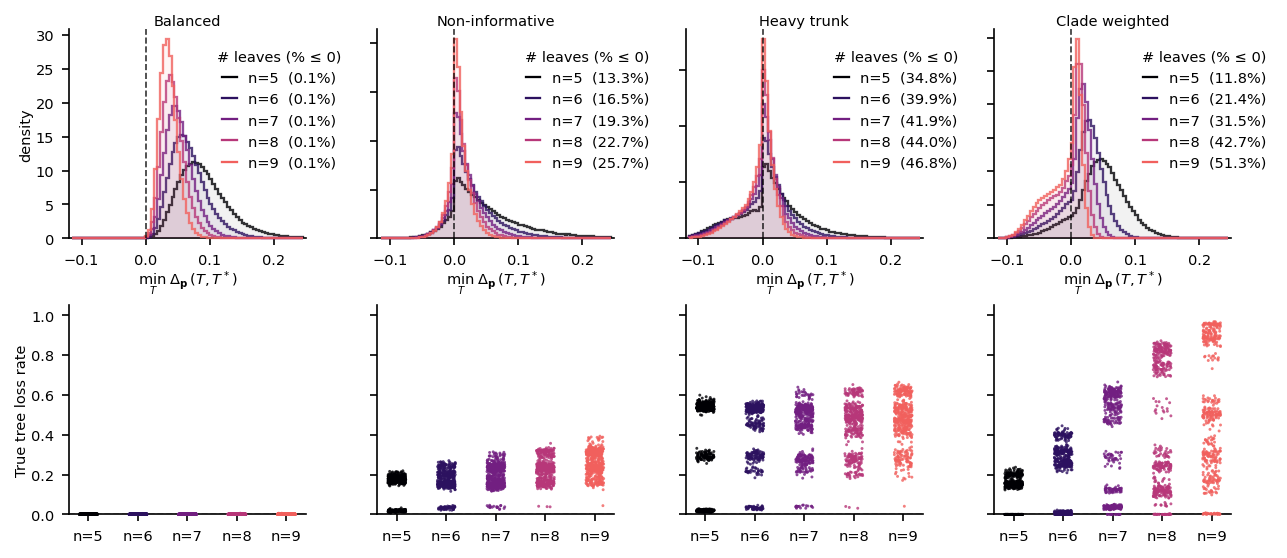

In [8]:
plot_margin_across_n_figure(results_by_n, win_rates_by_n, N_LEAVES_LIST)

## Topology Analysis

Fits random forest models predicting per-tree loss rate from topological features, then plots pairwise loss-rate scatter across priors, feature-vs-loss-rate panels, feature importances, and full per-feature grids.

In [9]:
topology_analysis = compute_topology_feature_analysis(
    bundle=bundle,
    priors=PRIORS,
    win_rates_by_n=win_rates_by_n,
    n_samples=N_SAMPLES,
    seed=SEED,
)

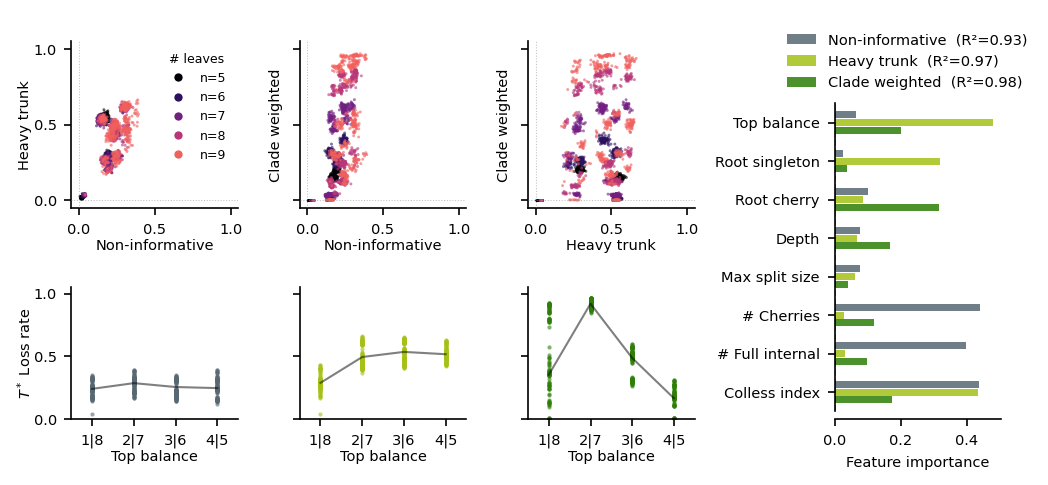

In [10]:
plot_topology_figure(topology_analysis, win_rates_by_n, N_LEAVES_LIST)

/Users/satasg/micromamba/envs/consistency/lib/python3.14/site-packages/statsmodels/nonparametric/smoothers_lowess.py:226: RuntimeWarning: invalid value encountered in divide
  res, _ = _lowess(y, x, x, np.ones_like(x),
/Users/satasg/micromamba/envs/consistency/lib/python3.14/site-packages/statsmodels/nonparametric/smoothers_lowess.py:226: RuntimeWarning: invalid value encountered in divide
  res, _ = _lowess(y, x, x, np.ones_like(x),
/Users/satasg/micromamba/envs/consistency/lib/python3.14/site-packages/statsmodels/nonparametric/smoothers_lowess.py:226: RuntimeWarning: invalid value encountered in divide
  res, _ = _lowess(y, x, x, np.ones_like(x),
/Users/satasg/micromamba/envs/consistency/lib/python3.14/site-packages/statsmodels/nonparametric/smoothers_lowess.py:226: RuntimeWarning: invalid value encountered in divide
  res, _ = _lowess(y, x, x, np.ones_like(x),
/Users/satasg/micromamba/envs/consistency/lib/python3.14/site-packages/statsmodels/nonparametric/smoothers_lowess.py:226: Ru

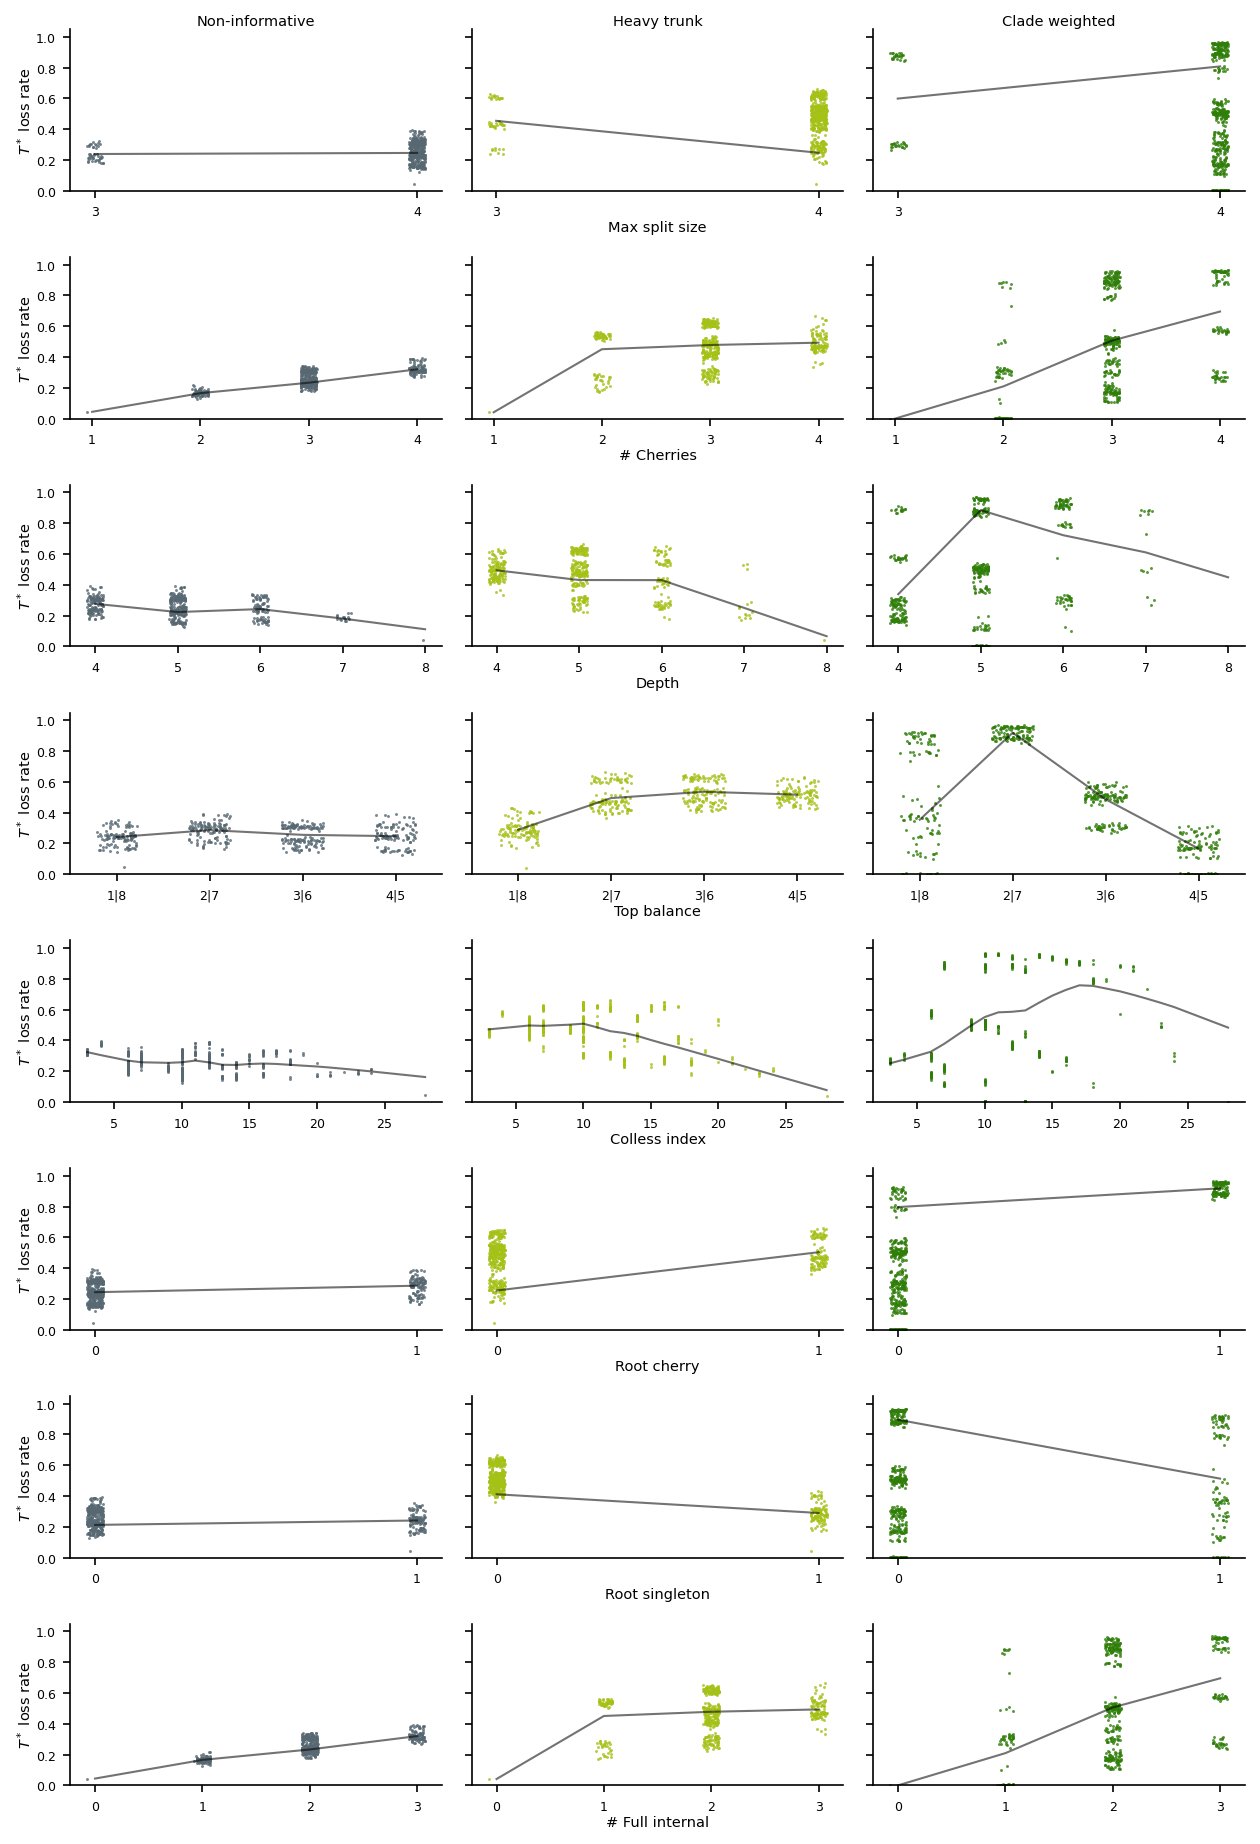

In [11]:
plot_all_topology_features(topology_analysis)

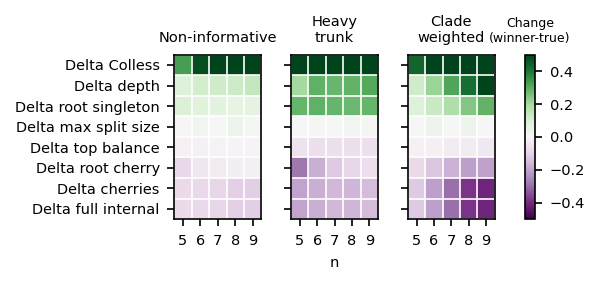

In [12]:
plot_winning_neighbor_heatmap(winning_neighbor_dfs, N_LEAVES_LIST)

In [13]:
with PdfPages(MULTIPAGE_FIGURE_PATH) as pdf:
    plot_margin_across_n_figure(results_by_n, win_rates_by_n, N_LEAVES_LIST, pdf=pdf, show=False)
    plot_topology_figure(topology_analysis, win_rates_by_n, N_LEAVES_LIST, pdf=pdf, show=False)
    plot_all_topology_features(topology_analysis, pdf=pdf, show=False)
    plot_winning_neighbor_heatmap(winning_neighbor_dfs, N_LEAVES_LIST, pdf=pdf, show=False)
print(f"Saved {MULTIPAGE_FIGURE_PATH}")

/Users/satasg/Documents/repos/inconsistency_repo/src/inconsistency_generation/nni_margin_plots.py:114: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()
/Users/satasg/micromamba/envs/consistency/lib/python3.14/site-packages/statsmodels/nonparametric/smoothers_lowess.py:226: RuntimeWarning: invalid value encountered in divide
  res, _ = _lowess(y, x, x, np.ones_like(x),
/Users/satasg/micromamba/envs/consistency/lib/python3.14/site-packages/statsmodels/nonparametric/smoothers_lowess.py:226: RuntimeWarning: invalid value encountered in divide
  res, _ = _lowess(y, x, x, np.ones_like(x),
/Users/satasg/micromamba/envs/consistency/lib/python3.14/site-packages/statsmodels/nonparametric/smoothers_lowess.py:226: RuntimeWarning: invalid value encountered in divide
  res, _ = _lowess(y, x, x, np.ones_like(x),
/Users/satasg/micromamba/envs/consistency/lib/python3.14/site-packages/statsmodels/nonparametric/smoothers

Saved /Users/satasg/Documents/repos/inconsistency_repo/figures/../figures/08_nni_margin_across_n_figures.pdf
